# Day 6 · Putting a number on a text
*Measuring Manuscripts*

Two classic measurements. *Zipf's law* ranks words by frequency and finds a strikingly regular curve. *Shannon entropy* reduces a text to one number: its average surprise. Both run on the sample. The harder task is deciding whether the number means anything.

## 1. Setup and text

> 🔧 *TO BUILD*: swap in the real material before class. Everything else runs as is.

In [12]:
import numpy as np, math
import urllib.request
import matplotlib.pyplot as plt
from collections import Counter

url = "https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/refs/heads/main/Workbook/Day%201%E2%80%94Traditional%20Philology/Canterbury%20Tales.txt"
sample = urllib.request.urlopen(url).read().decode("utf-8")

tokens = [w.lower().strip('.,;:!?') for w in sample.split()]
print(len(tokens), 'tokens,', len(set(tokens)), 'types')

6672 tokens, 1790 types


## 2. The Zipf curve

Rank the words from most to least common and plot rank against frequency on log–log axes. A nearly straight line appears, the signature of Zipf's law.

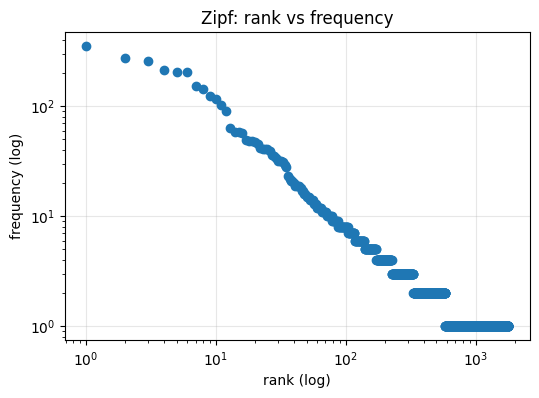

In [13]:
freq = Counter(tokens)
counts = np.array(sorted(freq.values(), reverse=True))
ranks = np.arange(1, len(counts) + 1)

plt.figure(figsize=(6, 4))
plt.loglog(ranks, counts, marker='o', linestyle='none')
plt.xlabel('rank (log)'); plt.ylabel('frequency (log)')
plt.title('Zipf: rank vs frequency'); plt.grid(alpha=0.3); plt.show()

## 3. Fit the slope

Zipf's law predicts a straight line with slope near −1. Fit a line to the log–log points and read off the slope. A short text is noisy, so don't expect exactly −1.

In [14]:
slope, intercept = np.polyfit(np.log(ranks), np.log(counts), 1)
print('Fitted slope:', round(slope, 2), '   (Zipf predicts about -1)')

Fitted slope: -0.81    (Zipf predicts about -1)


## Heaps' law: vocabulary growth

Zipf describes how often words repeat, while *Heaps' law* describes how fast new words arrive. Walk through the text token by token and record how many *distinct* words you have seen so far. Early on almost every word is new. Later, new words are rare and the curve flattens. Heaps' law says the vocabulary grows as a power of length, $V \approx K\,N^{\beta}$, with $\beta$ usually well below 1.

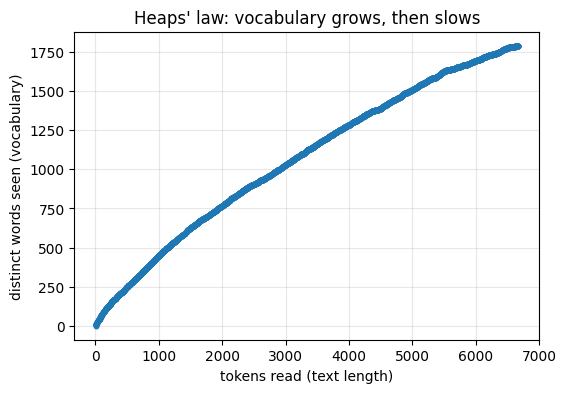

Fitted Heaps exponent beta = 0.78   (typically 0.4 to 0.6 for natural language)
Short sample, so treat the number as a demonstration, not a measurement.


In [ ]:
seen = set()
vocab_sizes = []
for i, w in enumerate(tokens, start=1):
    seen.add(w)
    vocab_sizes.append(len(seen))
token_counts = np.arange(1, len(tokens) + 1)

plt.figure(figsize=(6, 4))
plt.plot(token_counts, vocab_sizes, marker=".", linestyle="-")
plt.xlabel("tokens read (text length)"); plt.ylabel("distinct words seen (vocabulary)")
plt.title("Heaps' law: vocabulary grows, then slows"); plt.grid(alpha=0.3); plt.show()

# Fit the exponent on log-log axes (skip the first token to avoid log(1)=0 noise)
beta, logK = np.polyfit(np.log(token_counts[1:]), np.log(vocab_sizes[1:]), 1)
print(f"Fitted Heaps exponent beta = {beta:.2f}   (typically 0.4 to 0.6 for natural language)")

## 4. Entropy: average surprise

High entropy means the next word is hard to predict. Low entropy means it's easy. One number for the whole distribution, measured in bits.

In [16]:
def entropy(items):
    n = len(items)
    return -sum((c / n) * math.log2(c / n) for c in Counter(items).values())

print('Word entropy:', round(entropy(tokens), 2), 'bits per word')

Word entropy: 8.52 bits per word


### Entropy by hand, term by termThe `entropy` function above runs the same sum the Workbook works out on paper. Watch it build on a tiny string. We print each symbol's probability, its surprise in bits ($-\log_2 p$), and its weighted contribution ($p \times$ surprise). The contributions add up to the entropy.

In [17]:
tiny = "aaaabbcd"   # 8 symbols: A is common, C and D are rare
n = len(tiny)
counts = Counter(tiny)

H = 0.0
print(f"{'sym':>3} {'count':>5} {'p':>6} {'surprise':>9} {'p*surprise':>11}")
for sym in sorted(counts):
    c = counts[sym]
    p = c / n
    surprise = -math.log2(p)
    term = p * surprise
    H += term
    print(f"{sym:>3} {c:>5} {p:>6.3f} {surprise:>9.3f} {term:>11.3f}")

print("-" * 40)
print(f"Entropy H = {H:.3f} bits per symbol")
print(f"Maximum for {len(counts)} symbols = {math.log2(len(counts)):.3f} bits (all equally likely)")
print(f"Cross-check with entropy(): {entropy(list(tiny)):.3f} bits")

sym count      p  surprise  p*surprise
  a     4  0.500     1.000       0.500
  b     2  0.250     2.000       0.500
  c     1  0.125     3.000       0.375
  d     1  0.125     3.000       0.375
----------------------------------------
Entropy H = 1.750 bits per symbol
Maximum for 4 symbols = 2.000 bits (all equally likely)
Cross-check with entropy(): 1.750 bits


## 5. Characters vs words, and redundancy

Measure entropy at the character level too. Comparing it to the maximum possible entropy (if every symbol were equally likely) tells you how redundant the writing system is.

In [18]:
chars = [c for c in sample.lower() if c.isalpha()]
h_char = entropy(chars)
h_max = math.log2(len(set(chars)))
print('Character entropy:', round(h_char, 2), 'bits')
print('Maximum possible: ', round(h_max, 2), 'bits (if all letters were equally likely)')
print('Redundancy:       ', round(100 * (1 - h_char / h_max)), '%')

Character entropy: 4.13 bits
Maximum possible:  4.7 bits (if all letters were equally likely)
Redundancy:        12 %


### Predictability from context: bigramsPlain entropy treats every letter as a fresh guess. But in real language the previous letter narrows the next one: after `q` you expect `u`. *Conditional entropy* measures the next-letter surprise once the previous letter is known. It should come out lower than plain entropy, because context helps. We also report *perplexity* ($2^H$), the *effective number of choices*: an entropy of 2 bits behaves like 4 equally likely options.

In [19]:
# Plain (order-0) letter entropy, for comparison
h0 = entropy(chars)

# Conditional (order-1) entropy: average next-letter surprise given the previous letter
bigrams = list(zip(chars[:-1], chars[1:]))
prev_counts = Counter(chars[:-1])
bigram_counts = Counter(bigrams)

h1 = 0.0
for (a, b), c_ab in bigram_counts.items():
    p_ab = c_ab / len(bigrams)          # P(prev=a, next=b)
    p_b_given_a = c_ab / prev_counts[a] # P(next=b | prev=a)
    h1 -= p_ab * math.log2(p_b_given_a)

print(f"Plain letter entropy   H(next)        = {h0:.3f} bits   (perplexity {2**h0:.1f})")
print(f"Conditional entropy    H(next | prev) = {h1:.3f} bits   (perplexity {2**h1:.1f})")
print(f"Knowing the previous letter saves {h0 - h1:.3f} bits of surprise per letter.")

Plain letter entropy   H(next)        = 4.133 bits   (perplexity 17.6)
Conditional entropy    H(next | prev) = 3.497 bits   (perplexity 11.3)
Knowing the previous letter saves 0.636 bits of surprise per letter.


## 6. Compare two texts

Measurement is most useful in comparison. Shuffle the text into random word order and remeasure: entropy barely moves, because it ignores order entirely. That's a real limitation, worth knowing before you rely on it.

In [20]:
import random
shuffled = tokens[:]; random.Random(0).shuffle(shuffled)
print('Original entropy:', round(entropy(tokens), 3))
print('Shuffled entropy:', round(entropy(shuffled), 3))
print('Same numbers — word-entropy says nothing about word order.')

Original entropy: 8.519
Shuffled entropy: 8.519
Same numbers — word-entropy says nothing about word order.


## 7. The skeptic's test: random text is Zipfian too

This is the warning the day builds to. Generate gibberish (random letters with random spaces, no language at all) and it also produces a clean Zipf curve. A Zipf curve on your data proves little by itself. Always ask what a meaningless version would look like.

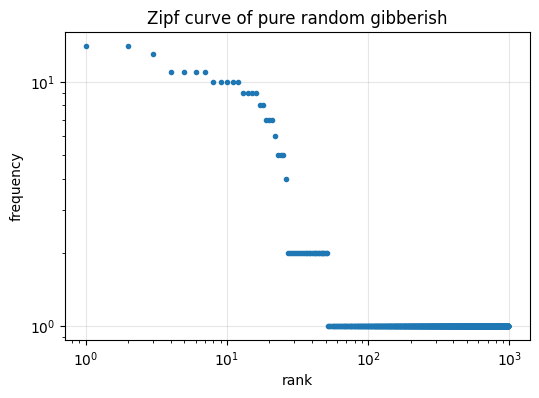

Looks just as Zipfian. Pattern-spotting is easy; meaning is the hard part.


In [21]:
rng = random.Random(1)
alphabet = 'abcdefghijklmnopqrstuvwxyz      '   # letters + spaces
gibberish = ''.join(rng.choice(alphabet) for _ in range(8000)).split()
g = np.array(sorted(Counter(gibberish).values(), reverse=True))

plt.figure(figsize=(6, 4))
plt.loglog(np.arange(1, len(g) + 1), g, marker='.', linestyle='none')
plt.title('Zipf curve of pure random gibberish'); plt.xlabel('rank'); plt.ylabel('frequency')
plt.grid(alpha=0.3); plt.show()
print('Looks just as Zipfian. Pattern-spotting is easy; meaning is the hard part.')

## A null model done properly

The shuffle and gibberish tests showed that some numbers survive when meaning is destroyed. Here is the skeptic's method as a recipe you can reuse. Suppose you measure a difference and want to know whether it is real. Build many *null* versions of the data in which the interesting structure is destroyed but the dull properties (length, letter counts) are kept, measure each, and see where your real number falls.

We test a concrete claim: **a real text has lower conditional (bigram) entropy than the same letters in random order**, because real language has letter-order structure and shuffled text does not. The shuffled baselines keep every letter and its count. They destroy only the order.

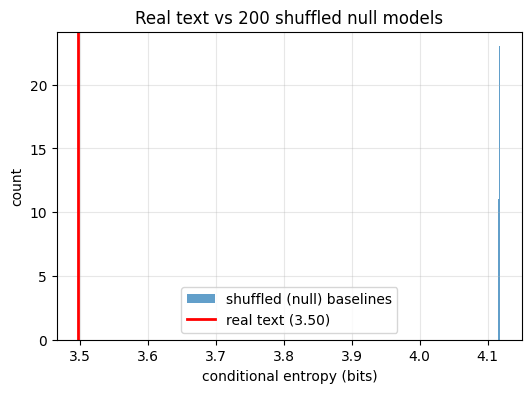

Real conditional entropy:    3.497 bits
Null mean (shuffled):        4.117 bits
Real result sits 0.620 bits below the null mean.
It falls outside the entire null spread: the order structure is real, not an artefact of length.


In [22]:
def cond_entropy(seq):
    """Order-1 conditional entropy of a letter sequence, in bits."""
    bg = list(zip(seq[:-1], seq[1:]))
    prev = Counter(seq[:-1])
    bgc = Counter(bg)
    h = 0.0
    for (a, b), c in bgc.items():
        h -= (c / len(bg)) * math.log2(c / prev[a])
    return h

real = cond_entropy(chars)

# Null distribution: shuffle the same letters many times, remeasure each
rng = random.Random(7)
null_values = []
for _ in range(200):
    shuf = chars[:]
    rng.shuffle(shuf)
    null_values.append(cond_entropy(shuf))
null_values = np.array(null_values)

plt.figure(figsize=(6, 4))
plt.hist(null_values, bins=20, alpha=0.7, label="shuffled (null) baselines")
plt.axvline(real, color="red", linewidth=2, label=f"real text ({real:.2f})")
plt.xlabel("conditional entropy (bits)"); plt.ylabel("count")
plt.title("Real text vs 200 shuffled null models"); plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f"Real conditional entropy:    {real:.3f} bits")
print(f"Null mean (shuffled):        {null_values.mean():.3f} bits")
print(f"Real result sits {(null_values.mean() - real):.3f} bits below the null mean.")
if real < null_values.min():
    print("It falls outside the entire null spread: the order structure is real, not an artefact of length.")
else:
    print("It overlaps the null spread: this sample is too small to rule out chance. Try a longer text.")

### Check-in
- What single number or distribution could your project measure?
- What would a null version of your data look like? If you can't tell it from your real result, you don't have a result yet.